In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

use_cuda = True 

#device = torch.device("cuda") if use_cuda and torch.cuda.is_available() else torch.device("cpu")
device = torch.device("cuda")
print(f"Using device: {device}")

Using device: cuda


In [2]:
def fit_plane(
        p1,
        p2,
        p3,
        eps:float = 1e-12,
        require_vertical: 
        bool = True, 
        vertical_co_thresh: float = 0.7
): 
   
   
    v1 = p2 - p3
    v2 = p3 - p1

    n = torch.cross(v1,v2,dim=0)
    mag_n = torch.linalg.norm(n)
    n = n/(mag_n + eps) 

    ok = (mag_n > eps) and (torch.abs(n[2]) >= vertical_co_thresh)

    d = -torch.dot(n,p1)

    return n,d,ok


In [3]:
def num_inliers(points, n, d,distance_thresh): 
    dist = (points@n + d).abs()
    mask_c = dist < distance_thresh
    inliers_c = int(mask_c.sum().item())
    return inliers_c,dist

In [4]:
def RANSAC(
    points: torch.Tensor,
    num_iters: int = 60,
    distance_thresh: float = 0.03,                
    min_inliers: int = 500,
    lowest_z_frac: float = 0.5,
    early_stop_inlier_ratio: float = 0.85,
    seed: int = 0,
    refine: bool = True,
):
    
    #Check points dimensions and move to GPU
    assert points.ndim == 2 and points.shape[1] == 3 
    device = points.device 

    N = points.shape[0]

    #determine candidate idx for RANSAC 
    if lowest_z_frac is not None and 0 < lowest_z_frac < 1.0:
        z = points[:,2]
        K = max(3,int(math.ceil(N*lowest_z_frac)))

        cand_idx = torch.topk(z, k=K, largest=False).indices
    else: 
        cand_idx = torch.arange(N, device=device)
    
    cand_points = points[cand_idx]
    K = cand_points.shape[0]

    #random generator on GPU 
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    #best guess variables 
    best_inliers = 0
    best_n,best_d = None,None
    best_mask = None

    for i in range(num_iters): 
        s = torch.randint(0,K, (3,),generator=g,device=device)
        p1,p2,p3 = cand_points[s[0]],cand_points[s[1]],cand_points[s[2]]

        n,d,ok = fit_plane(p1,p2,p3)

        if not bool(ok):
            continue 

        inliers_c,dist = num_inliers(points,n,d,distance_thresh) 
        if inliers_c > best_inliers:
            best_inliers = inliers_c
            best_n,best_d = n,d 

            best_mask = dist < distance_thresh

            if best_inliers/N >= early_stop_inlier_ratio:
                break 

    return best_n,best_d,best_mask


best_n: [-1.2991343e-04 -4.8337979e-04 -9.9999988e-01]
best_d: -0.0006878338754177094
TP=142 FP=0 FN=58 | Precision=1.000 Recall=0.710


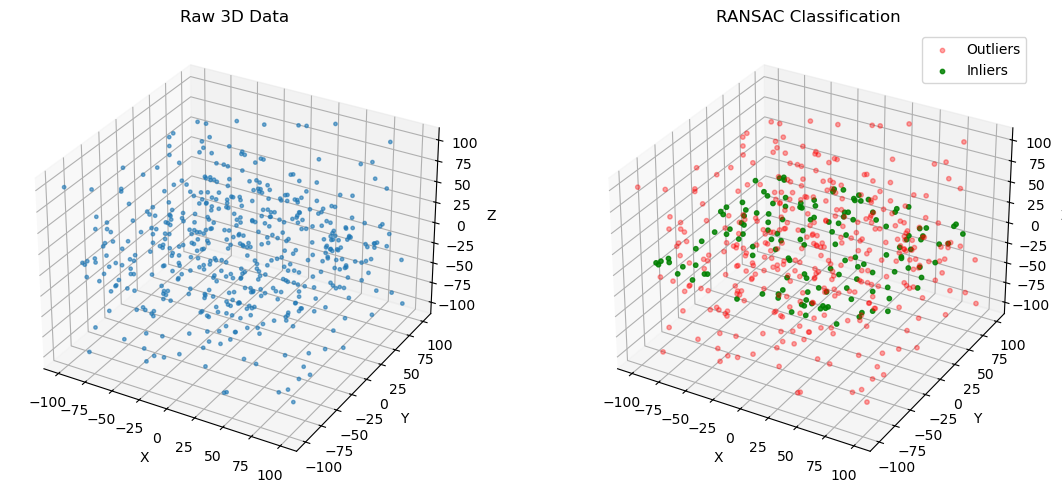

In [33]:
# ==========================
# TEST CELL - GPT GENERATED 
# Fixes fit_plane + RANSAC device bug
# Generates plane+outliers, runs RANSAC, plots results
# ============================

# -----------------------
# 1) Synthetic data (plane inliers + random outliers)
# -----------------------
def generate_plane_ransac_data_torch(
    n_inliers,
    n_outliers,
    plane_coeffs,  # ax + by + cz + d = 0
    xy_range=(-100, 100),
    noise_std=0.06,
    outlier_range=(-100, 100),
    seed=42,
    device=None,
    dtype=torch.float32,
):

    # Use numpy RNG then convert -> simplest reproducibility across CPU/GPU
    rng = np.random.default_rng(seed)
    a, b, c, d = plane_coeffs

    x = rng.uniform(xy_range[0], xy_range[1], n_inliers)
    y = rng.uniform(xy_range[0], xy_range[1], n_inliers)
    z = (-a * x - b * y - d) / c
    z += rng.normal(0, noise_std, n_inliers)
    inliers = np.stack([x, y, z], axis=1)

    outliers = rng.uniform(outlier_range[0], outlier_range[1], size=(n_outliers, 3))

    X_np = np.vstack([inliers, outliers]).astype(np.float32)

    gt_mask = np.zeros(X_np.shape[0], dtype=bool)
    gt_mask[:n_inliers] = True

    X = torch.tensor(X_np, device=device, dtype=dtype)
    gt_mask_t = torch.tensor(gt_mask, device=device)

    return X, gt_mask_t


# -----------------------
# 3) Plot helpers
# -----------------------
def plot_raw_and_classified(X: torch.Tensor, mask: torch.Tensor, title_suffix=""):
    Xc = X.detach().cpu().numpy()
    mc = mask.detach().cpu().numpy()

    fig = plt.figure(figsize=(12, 5))

    ax1 = fig.add_subplot(121, projection="3d")
    ax1.scatter(Xc[:, 0], Xc[:, 1], Xc[:, 2], s=6, alpha=0.6)
    ax1.set_title(f"Raw 3D Data {title_suffix}".strip())
    ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

    ax2 = fig.add_subplot(122, projection="3d")
    ax2.scatter(Xc[~mc, 0], Xc[~mc, 1], Xc[~mc, 2], c="red", s=10, alpha=0.35, label="Outliers")
    ax2.scatter(Xc[mc, 0], Xc[mc, 1], Xc[mc, 2], c="green", s=10, alpha=0.85, label="Inliers")
    ax2.set_title(f"RANSAC Classification {title_suffix}".strip())
    ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")
    ax2.legend()

    plt.tight_layout()
    plt.show()


def precision_recall(gt_mask: torch.Tensor, pred_mask: torch.Tensor):
    gt = gt_mask.bool()
    pr = pred_mask.bool()
    tp = (gt & pr).sum().item()
    fp = ((~gt) & pr).sum().item()
    fn = (gt & (~pr)).sum().item()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    return tp, fp, fn, precision, recall


# -----------------------
# 4) Run everything
# -----------------------
X, gt_mask = generate_plane_ransac_data_torch(
    n_inliers=200,
    n_outliers=300,
    plane_coeffs=(0, 0, 1, 0),
    noise_std=0.1,
    seed=42,
)

best_n, best_d, best_mask = RANSAC(
    X,
    num_iters=800,
    distance_thresh=0.10,
    min_inliers=100,
    lowest_z_frac=None,      # set e.g. 0.5 if you want to bias sampling
    early_stop_inlier_ratio=0.90,
    seed=0,
    require_vertical=False,  # set True if you want |nz| >= vertical_co_thresh
)

if best_mask is None:
    print("RANSAC failed to find a plane meeting min_inliers. Try increasing num_iters or lowering min_inliers.")
else:
    print("best_n:", best_n.detach().cpu().numpy())
    print("best_d:", float(best_d.detach().cpu()))
    tp, fp, fn, prec, rec = precision_recall(gt_mask, best_mask)
    print(f"TP={tp} FP={fp} FN={fn} | Precision={prec:.3f} Recall={rec:.3f}")

    plot_raw_and_classified(X, best_mask)
